# Imports

In [4]:
# Usual stuff
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Path
from pathlib import Path

# HDF5
import h5py

# RegEx
import re

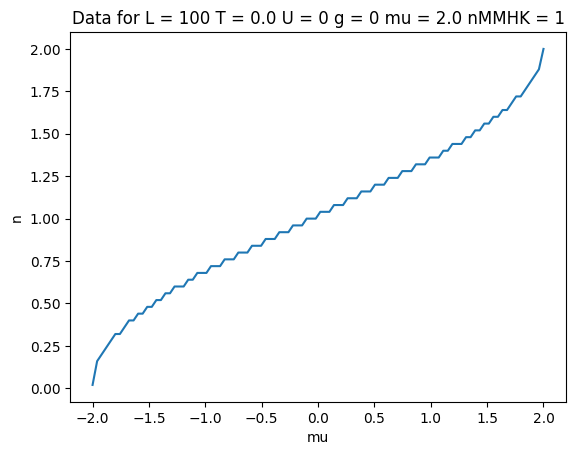

In [16]:
# Get the directory where the script is located
current_dir = Path.cwd()

# Get the output directory
current_out = current_dir / "outputs"

# Iterate through all items in the folder
for file in current_out.iterdir():
    if file.is_file():
        if str(file.suffix) == ".h5":

            # Open the HDF5 file in read mode
            with h5py.File(current_out / file.name, "r") as file:
                
                # Read root-level outputs
                # Using [()] extracts the dataset into a NumPy array
                x_data = file["x_data"][()]
                y_data = file["y_data"][()]
                out1 = file["out1"][()].decode('utf-8')
                
                # Read parameters from the 'params' group into a Python dictionary
                params = {}
                if "params" in file:
                    for key in file["params"].keys():
                        # Extract the value.
                        # If it's a 0D scalar array .item() converts it to a standard Python float/int
                        val = file["params"][key][()]
                        if isinstance(val, np.ndarray) and val.ndim == 0:
                            params[key] = val.item()
                        else:
                            params[key] = val
                            
                # Read sweep data from the 'sweep1' group into a Python dictionary
                sweep1 = {}
                if "sweep1" in file:
                    for key in file["sweep1"].keys():
                        val = file["sweep1"][key][()]
                        if isinstance(val, np.ndarray) and val.ndim == 0:
                            sweep1[key] = val.item()
                        else:
                            sweep1[key] = val
                
                # Title for the plot
                title_str = "Data for " + " ".join(
                    f"{key} = {value}" if key != sweep1["param"] else "" for key, value in params.items()
                )

                # Make the plot
                plt.plot(x_data, y_data)
                plt.title(title_str)
                plt.xlabel(sweep1["param"].decode('utf-8'))
                plt.ylabel(out1)
                plt.show()